In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

2026-04-25 03:37:40.226270: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777088260.408485      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777088260.461476      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777088260.872871      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777088260.872946      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777088260.872950      55 computation_placer.cc:177] computation placer alr

In [2]:
base_dir = "/kaggle/input/datasets/insyirahazman/menstrual-blood-color/data_256_256"

In [3]:
rows = []
for label in sorted(os.listdir(base_dir)):
    class_dir = os.path.join(base_dir, label)
    if not os.path.isdir(class_dir):
        continue
    for fname in sorted(os.listdir(class_dir)):
        if fname.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.webp')):
            rows.append({'filepath': os.path.join(class_dir, fname), 'label': label})
df = pd.DataFrame(rows)
print(df.head())

                                            filepath  label
0  /kaggle/input/datasets/insyirahazman/menstrual...  Black
1  /kaggle/input/datasets/insyirahazman/menstrual...  Black
2  /kaggle/input/datasets/insyirahazman/menstrual...  Black
3  /kaggle/input/datasets/insyirahazman/menstrual...  Black
4  /kaggle/input/datasets/insyirahazman/menstrual...  Black


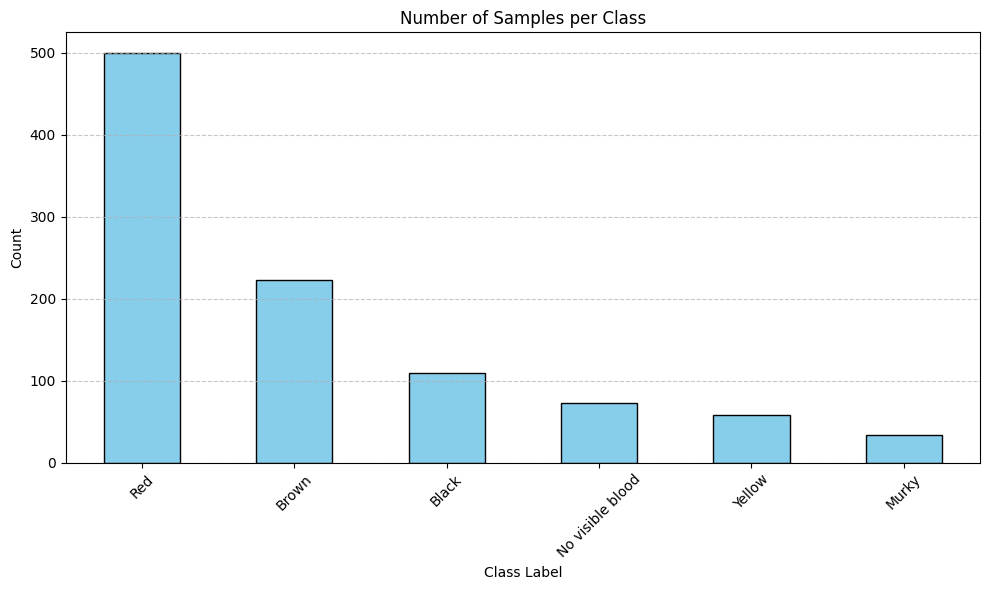

In [4]:
class_counts = df['label'].value_counts()
plt.figure(figsize=(10, 6))
class_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Number of Samples per Class')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

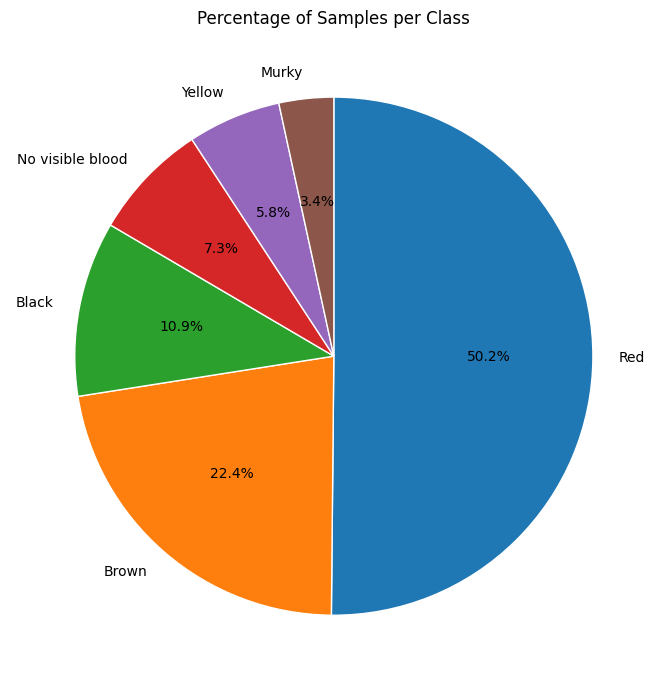

In [5]:
class_counts = df['label'].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(
    class_counts.values,
    labels=class_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    wedgeprops={'edgecolor': 'white'}
)
plt.title('Percentage of Samples per Class')
plt.tight_layout()
plt.show()

## Pre-Processing

In [6]:
print("Loading images...")
images = []
labels = []
for i, row in df.iterrows():
    try:
        img = load_img(row["filepath"], target_size=(256, 256))
        img_array = img_to_array(img) / 255.0  # normalize
        images.append(img_array)
        labels.append(row["label"])
        
        if (i + 1) % 100 == 0:
            print(f"Loaded {i + 1} images.")
    except Exception as e:
        print(f"Error loading {row['filepath']}: {e}")

Loading images...
Loaded 100 images.
Loaded 200 images.
Loaded 300 images.
Loaded 400 images.
Loaded 500 images.
Loaded 600 images.
Loaded 700 images.
Loaded 800 images.
Loaded 900 images.


In [7]:
images = np.array(images)
labels = np.array(labels)
print(f"Images shape: {images.shape}, Labels shape: {labels.shape}")

Images shape: (997, 256, 256, 3), Labels shape: (997,)


In [8]:
# Encode labels
le = LabelEncoder()
labels_int = le.fit_transform(labels)
labels_onehot = to_categorical(labels_int)

print("Integer labels (first 5):", labels_int[:5])
print("One-hot labels (first 5):", labels_onehot[:5])
print("Classes:", le.classes_)

num_classes = len(le.classes_)
print(f"Number of classes: {num_classes}")

Integer labels (first 5): [0 0 0 0 0]
One-hot labels (first 5): [[1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0.]]
Classes: ['Black' 'Brown' 'Murky' 'No visible blood' 'Red' 'Yellow']
Number of classes: 6


## Split

In [9]:
# First split: 80% train+val, 20% test
X_temp, X_test, y_temp, y_test, labels_temp, labels_test = train_test_split(
    images, labels_onehot, labels_int, 
    test_size=0.2, random_state=42, stratify=labels_int
)

In [10]:
X_train, X_val, y_train, y_val, labels_train, labels_val = train_test_split(
    X_temp, y_temp, labels_temp,
    test_size=0.25, random_state=42, stratify=labels_temp  
)

In [11]:
print(f"Train set: {X_train.shape}, {y_train.shape}")
print(f"Validation set: {X_val.shape}, {y_val.shape}")
print(f"Test set: {X_test.shape}, {y_test.shape}")

Train set: (597, 256, 256, 3), (597, 6)
Validation set: (200, 256, 256, 3), (200, 6)
Test set: (200, 256, 256, 3), (200, 6)


## Model

In [12]:
import tensorflow.keras.backend as K
def focal_loss(alpha=0.25, gamma=2.0):
    """
    Focal Loss for addressing class imbalance
    alpha: weighting factor for rare class (default 0.25)
    gamma: focusing parameter (default 2.0)
    """
    def focal_loss_fixed(y_true, y_pred):
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1 - epsilon)
        
        # calculate cross entropy
        ce = -y_true * K.log(y_pred)
        
        # calculate focal weight: (1-pt)^gamma
        pt = K.sum(y_true * y_pred, axis=-1, keepdims=True)
        focal_weight = K.pow(1 - pt, gamma)
        
        # alpha weighting
        alpha_weight = y_true * alpha + (1 - y_true) * (1 - alpha)
        
        # components
        focal = alpha_weight * focal_weight * ce
        return K.mean(K.sum(focal, axis=-1))
    
    return focal_loss_fixed

In [13]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

In [14]:
# classifier head for all models
def create_classifier_head(base_model, num_classes):
    model = tf.keras.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

In [15]:
def create_resnet_model(input_shape, num_classes):
    base_model = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    base_model.trainable = True
    return create_classifier_head(base_model, num_classes)

In [16]:
model = create_resnet_model((256, 256, 3), num_classes)
model_name = "ResNet50"

model.compile(
    optimizer=Adam(learning_rate=0.0001),  # lower learning rate since using pretrained weights
    loss=focal_loss(alpha=0.25, gamma=2.0),  
    metrics=['accuracy']
)

model.summary()

I0000 00:00:1777088292.339031      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777088292.344899      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 8, 8, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,777,862 (94.52 MB)

 Trainable params: 24,720,646 (94.30 MB)

 Non-trainable params: 57,216 (223.50 KB)

In [17]:
# Callbacks
model_path = '/kaggle/working/resnet50_baseline.h5'
checkpoint = ModelCheckpoint(
    model_path,
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    mode='max',
    verbose=1,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-8,
    verbose=1
)

In [18]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=16,
    callbacks=[checkpoint, early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/30


I0000 00:00:1777088328.261340     125 service.cc:152] XLA service 0x7cf288004420 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777088328.261407     125 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777088328.261414     125 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777088334.294358     125 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-25 03:39:01.984478: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 03:39:02.133255: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1777088356.206058     125 device_co

37/38 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.3535 - loss: 0.3980

2026-04-25 03:39:32.524100: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 03:39:32.670620: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 800ms/step - accuracy: 0.3562 - loss: 0.3962
Epoch 1: val_accuracy improved from -inf to 0.50000, saving model to /kaggle/working/resnet50_baseline.h5


38/38 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.3588 - loss: 0.3945 - val_accuracy: 0.5000 - val_loss: 0.2528 - learning_rate: 1.0000e-04
Epoch 2/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.6106 - loss: 0.1780
Epoch 2: val_accuracy did not improve from 0.50000
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 196ms/step - accuracy: 0.6115 - loss: 0.1775 - val_accuracy: 0.5000 - val_loss: 0.8282 - learning_rate: 1.0000e-04
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.7203 - loss: 0.1113
Epoch 3: val_accuracy did not improve from 0.50000
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 198ms/step - accuracy: 0.7210 - loss: 0.1109 - val_accuracy: 0.5000 - val_loss: 1.7182 - learning_rate: 1.0000e-04
Epoch 4/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.7547 - loss: 0.0930
Epoch 4: val_accuracy did not improve from 0.50000
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 199ms/step - accuracy: 0.7554 - loss: 0.0929 - val_accuracy: 0.5000 - val_loss: 1.9866 - learning_rate: 1.0000e-04
Epoch 5/30


In [19]:
loss, accuracy = model.evaluate(X_train, y_train)
print(f"Train Accuracy: {accuracy*100:.2f}%")

19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 333ms/step - accuracy: 0.5040 - loss: 0.2662
Train Accuracy: 50.25%


In [20]:
val_loss, val_acc = model.evaluate(X_val, y_val)
print(f"Validation Accuracy: {val_acc*100:.2f}%")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.4639 - loss: 0.2595 
Validation Accuracy: 50.00%


## Loss and Accuracy Matrices

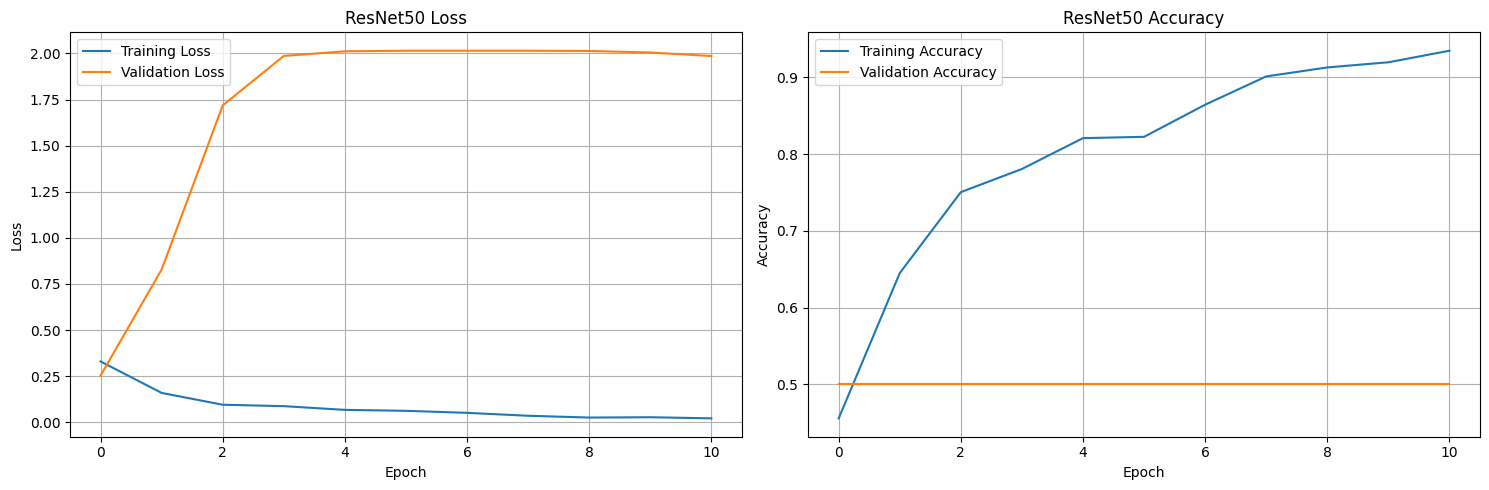

In [32]:
# Plot training history
plt.figure(figsize=(15, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('ResNet50 Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('ResNet50 Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Other Matrices

In [24]:
# Load the best model
best_model = tf.keras.models.load_model(
    model_path,
    custom_objects={'focal_loss_fixed': focal_loss()}
)

In [25]:
train_preds = np.argmax(best_model.predict(X_train, batch_size=16), axis=1)
val_preds = np.argmax(best_model.predict(X_val, batch_size=16), axis=1)
test_preds = np.argmax(best_model.predict(X_test, batch_size=16), axis=1)

38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 158ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 206ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step


In [26]:
y_train_int = np.argmax(y_train, axis=1)
y_val_int = np.argmax(y_val, axis=1)
y_test_int = np.argmax(y_test, axis=1)

In [27]:
train_accuracy = np.mean(y_train_int == train_preds)
val_accuracy = np.mean(y_val_int == val_preds)
test_accuracy = np.mean(y_test_int == test_preds)

print(f"\nFinal Results using Pretrained {model_name} with Focal Loss:")
print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


Final Results using Pretrained ResNet50 with Focal Loss:
Train Accuracy: 0.5025
Validation Accuracy: 0.5000
Test Accuracy: 0.5000


In [28]:
# Detailed classification report for test set
print("\n=== Train Set Classification Report ===")
print(classification_report(y_train_int, train_preds, target_names=le.classes_))


=== Train Set Classification Report ===
                  precision    recall  f1-score   support

           Black       0.00      0.00      0.00        65
           Brown       0.00      0.00      0.00       133
           Murky       0.00      0.00      0.00        20
No visible blood       0.00      0.00      0.00        44
             Red       0.50      1.00      0.67       300
          Yellow       0.00      0.00      0.00        35

        accuracy                           0.50       597
       macro avg       0.08      0.17      0.11       597
    weighted avg       0.25      0.50      0.34       597



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [29]:
# Detailed classification report for test set
print("\n=== Validation Set Classification Report ===")
print(classification_report(y_val_int, val_preds, target_names=le.classes_))


=== Validation Set Classification Report ===
                  precision    recall  f1-score   support

           Black       0.00      0.00      0.00        22
           Brown       0.00      0.00      0.00        45
           Murky       0.00      0.00      0.00         7
No visible blood       0.00      0.00      0.00        14
             Red       0.50      1.00      0.67       100
          Yellow       0.00      0.00      0.00        12

        accuracy                           0.50       200
       macro avg       0.08      0.17      0.11       200
    weighted avg       0.25      0.50      0.33       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [30]:
# Detailed classification report for test set
print("\n=== Test Set Classification Report ===")
print(classification_report(y_test_int, test_preds, target_names=le.classes_))


=== Test Set Classification Report ===
                  precision    recall  f1-score   support

           Black       0.00      0.00      0.00        22
           Brown       0.00      0.00      0.00        45
           Murky       0.00      0.00      0.00         7
No visible blood       0.00      0.00      0.00        15
             Red       0.50      1.00      0.67       100
          Yellow       0.00      0.00      0.00        11

        accuracy                           0.50       200
       macro avg       0.08      0.17      0.11       200
    weighted avg       0.25      0.50      0.33       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


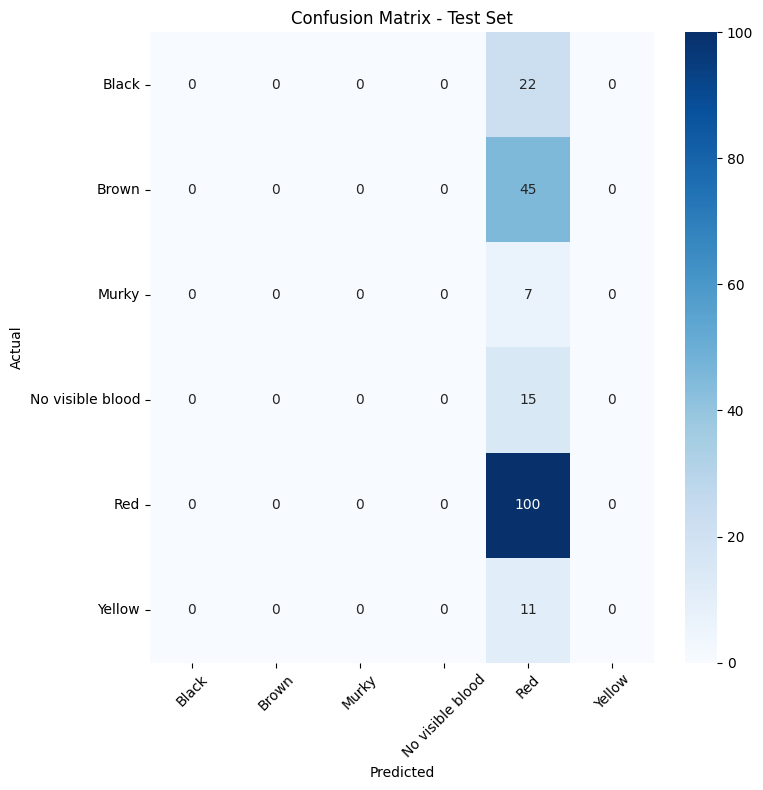

In [31]:
# Confusion Matrix for test set
plt.figure(figsize=(8, 8))
cm = confusion_matrix(y_test_int, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()